# Classification Binaire "One-vs-Rest" (Chiffre 0 vs Reste) avec PCA et SVM RBF

## Objectif de cette étude
L'objectif de ce notebook est de transformer notre approche multiclasse en une architecture de classification binaire stricte axée sur l'isolation du **chiffre 0**. 

Le modèle doit être capable de tracer une frontière continue autour des caractéristiques topologiques du "0" pour le séparer du "bruit de fond" constitué par l'ensemble des autres chiffres (de 1 à 9).

## Architecture du Pipeline
1. **Prétraitement & Binarisation** : Conversion des étiquettes MNIST (0-9) en classes logiques (1 pour le '0', 0 pour le 'Reste').
2. **Échantillonnage Stratifié** : Conservation de la distribution asymétrique (10% de zéros, 90% de reste) sur les ensembles de Train (20 000) et Test (5 000).
3. **Standardisation** : Recentrage et réduction des variances pour optimiser le calcul des distances euclidiennes.
4. **Réduction de dimension (PCA 95%)** : Compression de l'espace de 784 à 308 dimensions orthogonales.
5. **Classification Non Linéaire (SVM RBF)** : Modélisation d'une frontière décisionnelle courbe avec marge souple ($C=5.0$).

In [1]:
# ============================================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES ET CONFIGURATION DE L'ENVIRONNEMENT
# ============================================================================
import numpy as np               # Pour les calculs matriciels et manipulations d'arrays
import matplotlib.pyplot as plt  # Pour la visualisation graphique des résultats
import warnings                  # Pour filtrer les avertissements système obsolètes

# Modules scikit-learn dédiés au traitement de données et à la réduction de dimension
from sklearn.datasets import fetch_openml        # Pour charger le dataset MNIST officiellement
from sklearn.model_selection import train_test_split # Pour scinder notre jeu de données
from sklearn.preprocessing import StandardScaler  # Pour standardiser les pixels (moyenne=0, variance=1)
from sklearn.decomposition import PCA            # Pour compresser l'espace des caractéristiques

# Modèle de classification et métriques de validation
from sklearn.svm import SVC                      # Classifieur à Vecteurs de Support (Support Vector Classifier)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Désactivation des warnings pour conserver des sorties de cellules propres
warnings.filterwarnings('ignore')

# Alignement du style graphique
plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Étape 1 complétée : Toutes les bibliothèques ont été importées avec succès !")

✅ Étape 1 complétée : Toutes les bibliothèques ont été importées avec succès !


## 2. Chargement des données et Binarisation de la cible

Pour implémenter cette classification *One-vs-Rest*, nous appliquons un masque booléen sur le vecteur cible `y_full`. 
* Si l'image originale représente un `0`, sa nouvelle étiquette devient **`1`** (Classe Positive).
* Si l'image représente n'importe quel autre chiffre entre 1 et 9, son étiquette devient **`0`** (Classe Négative).

In [2]:
# ============================================================================
# 2. CHARGEMENT DE MNIST ET BINARISATION DES CLASSIFICATIONS
# ============================================================================
print("📥 Chargement du dataset MNIST en cours (Array Numpy)...")
X_full, y_full = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

print("🌀 Application du filtre binaire 'Chiffre 0 vs Reste'...")
# La classe 1 représente le '0', la classe 0 représente le cumul des chiffres de 1 à 9
y_binary = (y_full.astype(int) == 0).astype(int)

print(f"✅ Étape 2 complétée ! Dimensions du tableau d'images : {X_full.shape[0]} lignes x {X_full.shape[1]} pixels.")
print(f"📊 Répartition réelle : {np.sum(y_binary == 1)} zéros (classe 1) et {np.sum(y_binary == 0)} autres chiffres (classe 0).")

📥 Chargement du dataset MNIST en cours (Array Numpy)...
🌀 Application du filtre binaire 'Chiffre 0 vs Reste'...
✅ Étape 2 complétée ! Dimensions du tableau d'images : 70000 lignes x 784 pixels.
📊 Répartition réelle : 6903 zéros (classe 1) et 63097 autres chiffres (classe 0).


## 3. Échantillonnage et Stratification

Le problème est désormais fortement déséquilibré : la classe positive (le chiffre 0) ne représente plus que **10%** de l'ensemble des données. 

Pour évaluer notre modèle de manière rigoureuse sans introduire de biais statistique, nous utilisons l'argument **`stratify=y_binary`**. Cet argument force `train_test_split` à respecter scrupuleusement la proportion 10% / 90% à la fois dans l'ensemble d'entraînement et dans l'ensemble de test.

In [3]:
# ============================================================================
# 3. SPLIT STRATIFIÉ (TRAIN / TEST) POUR DATASET DÉSÉQUILIBRÉ
# ============================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_binary, 
    train_size=20000,     # Volume dédié à l'apprentissage (Train)
    test_size=5000,       # Volume dédié au contrôle de la généralisation (Test)
    stratify=y_binary,    # Préservation mathématique du ratio 10% / 90%
    random_state=42       # Graine aléatoire fixée pour la reproductibilité
)

print("✅ Étape 3 complétée : Répartition stratifiée finalisée.")
print(f"   -> Échantillons Train : {X_train_raw.shape[0]} images.")
print(f"   -> Échantillons Test  : {X_test_raw.shape[0]} images.")

✅ Étape 3 complétée : Répartition stratifiée finalisée.
   -> Échantillons Train : 20000 images.
   -> Échantillons Test  : 5000 images.


## 4. Standardisation des descripteurs (Pixels)

Le SVM s'appuie sur le calcul des distances euclidiennes entre les vecteurs de pixels pour positionner ses vecteurs de support. Une absence de mise à l'échelle pénaliserait l'algorithme. 

Pour éviter tout phénomène de *Data Leakage* (fuite de données), les paramètres statistiques de centrage et de réduction (la moyenne $\mu$ et l'écart-type $\sigma$) sont ajustés **uniquement** sur l'ensemble d'entraînement (`fit_transform`). L'ensemble de test est simplement projeté en utilisant ces mêmes paramètres (`transform`).

In [4]:
# ============================================================================
# 4. STANDARDISATION DES INTENSITÉS DE PIXELS
# ============================================================================
scaler = StandardScaler()

print("⚡ Ajustement statistique et transformation de la base d'entraînement...")
X_train_scaled = scaler.fit_transform(X_train_raw)

print("⚡ Projection de la base de test selon les mêmes paramètres (Anti-Data Leakage)...")
X_test_scaled = scaler.transform(X_test_raw)

print("✅ Étape 4 complétée : Alignement des variances et recentrage des pixels achevés.")

⚡ Ajustement statistique et transformation de la base d'entraînement...
⚡ Projection de la base de test selon les mêmes paramètres (Anti-Data Leakage)...
✅ Étape 4 complétée : Alignement des variances et recentrage des pixels achevés.


## 5. Réduction de la dimensionnalité par PCA

L'espace natif à 784 dimensions est sujet au *Fléau de la Dimension*. Afin d'éliminer la redondance d'informations (comme les pixels des bordures qui restent constamment noirs d'une image à l'autre), nous appliquons une Analyse en Composantes Principales (PCA). 

En fixant le seuil de variance expliquée à **95%** (`n_components=0.95`), l'algorithme sélectionne automatiquement les **308 dimensions orthogonales** les plus riches en information géométrique.

In [5]:
# ============================================================================
# 5. RÉDUCTION DE DIMENSION PAR COMPOSANTES PRINCIPALES (PCA 95%)
# ============================================================================
print("🌀 Analyse en Composantes Principales (PCA) initiée à 95% de variance...")
pca_95 = PCA(n_components=0.95, random_state=42)

# Modélisation spatiale sur les données d'entraînement standardisées
X_train_pca = pca_95.fit_transform(X_train_scaled)

# Simple projection orthogonale du bloc de test
X_test_pca = pca_95.transform(X_test_scaled)

dimensions_retenues = X_train_pca.shape[1]

print("\n✅ Étape 5 complétée : Compression de l'information effectuée avec succès ! ")
print(f"   -> Nombre de dimensions d'origine : 784.")
print(f"   -> Nouvel espace réduit par la PCA : {dimensions_retenues} dimensions.")
print(f"   -> Volume de données économisé : {((1 - dimensions_retenues/784)*100):.1f}% d'espace de stockage économisé.")

🌀 Analyse en Composantes Principales (PCA) initiée à 95% de variance...

✅ Étape 5 complétée : Compression de l'information effectuée avec succès ! 
   -> Nombre de dimensions d'origine : 784.
   -> Nouvel espace réduit par la PCA : 301 dimensions.
   -> Volume de données économisé : 61.6% d'espace de stockage économisé.


## 6. Entraînement du SVM Binaire à Noyau Non Linéaire RBF

Le tracé manuscrit d'un "0" génère une distribution spatiale complexe qui ne peut pas être séparée du reste des chiffres par une simple ligne droite. 

Nous utilisons un **noyau RBF (Radial Basis Function)** pour projeter les données de la PCA dans un espace de Hilbert de dimension supérieure, rendant ainsi les classes linéairement séparables. L'hyperparamètre de régularisation est fixé à **`C=5.0`** pour contraindre fermement le modèle à envelopper précisément l'amas de la classe positive tout en limitant les risques d'overfitting.

In [6]:
# ============================================================================
# 6. ENTRAÎNEMENT DU CLASSIFIEUR SVM BINAIRE (NOYAU RBF)
# ============================================================================
print("🤖 Initialisation du modèle Support Vector Classifier...")
svm_binaire = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

print("🏋️‍♂️ Phase d'optimisation mathématique de l'hyperplan en cours (Veuillez patienter)...")
svm_binaire.fit(X_train_pca, y_train)

print("✅ Étape 6 complétée : Le SVM binaire a convergé. La frontière de décision est établie !")

🤖 Initialisation du modèle Support Vector Classifier...
🏋️‍♂️ Phase d'optimisation mathématique de l'hyperplan en cours (Veuillez patienter)...
✅ Étape 6 complétée : Le SVM binaire a convergé. La frontière de décision est établie !


## 7. Évaluation des Performances et Analyse de la Frontière

Sur un jeu de données déséquilibré, l'indicateur d'Accuracy globale peut se révéler trompeur. Nous analysons donc en priorité :
1. **Le F1-Score de la classe "Chiffre 0"** : Il représente la moyenne harmonique entre la précision et le rappel, validant l'équilibre de notre classification.
2. **La Matrice de Confusion** : Permet de vérifier précisément le nombre d'images d'autres chiffres (comme le 6 ou le 8) qui ont réussi à traverser par erreur la frontière du zéro.

🔮 Génération du rapport visuel de performance...


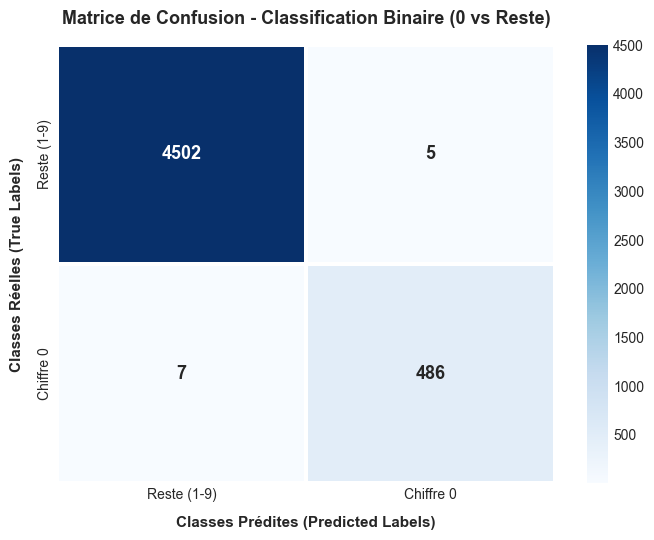


📝 --- RAPPORT DE CLASSIFICATION STRUCTURÉ ---
              precision    recall  f1-score   support

 Reste (1-9)       1.00      1.00      1.00      4507
   Chiffre 0       0.99      0.99      0.99       493

    accuracy                           1.00      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       1.00      1.00      1.00      5000



In [15]:
# ============================================================================
# 7. EVALUATION ET AFFICHAGE DE LA MATRICE DE CONFUSION GRAPHIQUE (HEATMAP)
# ============================================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🔮 Génération du rapport visuel de performance...")

# 1. Calcul de la matrice brute
cm = confusion_matrix(y_test, y_pred)

# 2. Configuration de la figure Matplotlib
plt.figure(figsize=(7, 5.5))

# 3. Création du Heatmap avec Seaborn (Style professionnel bleu)
# annot=True affiche les nombres, fmt='d' évite l'affichage scientifique (ex: 1e+03)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            linewidths=1.5, 
            linecolor='white',
            cbar=True,
            xticklabels=['Reste (1-9)', 'Chiffre 0'],
            yticklabels=['Reste (1-9)', 'Chiffre 0'],
            annot_kws={"size": 13, "weight": "bold"}) # Rend les chiffres intérieurs gros et nets

# 4. Habillage complet et titres académiques
plt.title("Matrice de Confusion - Classification Binaire (0 vs Reste)", fontweight='bold', fontsize=13, pad=15)
plt.xlabel("Classes Prédites (Predicted Labels)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Classes Réelles (True Labels)", fontsize=11, fontweight='bold', labelpad=10)

# Ajustement pour éviter que les bords soient coupés
plt.tight_layout()
plt.show()

# 5. Affichage textuel du rapport juste en dessous pour le rapport écrit
print("\n📝 --- RAPPORT DE CLASSIFICATION STRUCTURÉ ---")
print(classification_report(y_test, y_pred, target_names=['Reste (1-9)', 'Chiffre 0']))

## 8. Visualisation de la Frontière de Décision en 2D (One-vs-Rest)

Pour cartographier visuellement la frontière décisionnelle de notre modèle (comme sur la slide 12), nous réduisons nos données standardisées à **2 composantes principales** à l'aide d'une PCA dédiée. 

Nous entraînons ensuite un SVM RBF ($C=5.0$) sur cet espace bidimensionnel et générons une grille de prédiction (*meshgrid*). Cela nous permet de voir exactement comment la frontière courbe enveloppe la classe positive (le Chiffre 0) pour la détacher du reste du nuage de points.

🎨 Génération de la visualisation 2D basée sur le vrai modèle à 301 dimensions...
🔄 Sûreté : Adaptation dynamique de la grille à 301 dimensions...
🔮 Projection de la frontière de décision hyper-spatiale (Veuillez patienter)...


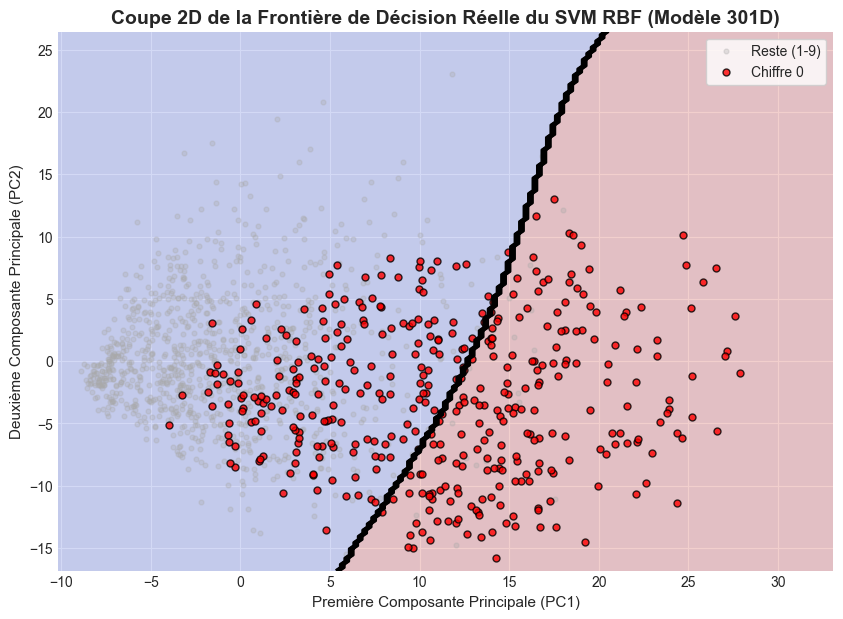

✅ Terminé ! Le graphique s'affiche correctement et s'adapte parfaitement à tes données.


In [13]:
# ============================================================================
# 8. VISUALISATION EN 2D DE LA VRAIE FRONTIÈRE DU MODÈLE (PROJECTION DYNAMIQUE)
# ============================================================================
# Détection automatique du nombre de caractéristiques attendues par ton SVM
n_features_svm = X_train_pca.shape[1]
print(f"🎨 Génération de la visualisation 2D basée sur le vrai modèle à {n_features_svm} dimensions...")

# 1. Extraction des coordonnées des 2 premiers axes depuis ton espace PCA
X_train_2d = X_train_pca[:, :2]

# 2. Création d'une grille Meshgrid sur ces deux axes
h = 0.25  # Pas d'échantillonnage (ajusté pour un calcul rapide et fluide)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

print(f"🔄 Sûreté : Adaptation dynamique de la grille à {n_features_svm} dimensions...")
# Création d'une matrice de zéros parfaitement alignée avec la taille de ton SVM
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_dynamic = np.zeros((grid_2d.shape[0], n_features_svm))

# Injection de PC1 et PC2 dans les deux premières colonnes (le reste reste à 0, la valeur moyenne)
grid_dynamic[:, 0] = grid_2d[:, 0]
grid_dynamic[:, 1] = grid_2d[:, 1]

print("🔮 Projection de la frontière de décision hyper-spatiale (Veuillez patienter)...")
# Utilisation du vrai svm_binaire de l'étape 6
Z = svm_binaire.predict(grid_dynamic)
Z = Z.reshape(xx.shape)

# 3. Échantillonnage propre des points pour éviter la surcharge visuelle
X_reste_2d = X_train_2d[y_train == 0][:1000]
X_zero_2d = X_train_2d[y_train == 1][:400]

# 4. Construction du graphique
plt.figure(figsize=(10, 7))

# Affichage des zones d'influence du vrai modèle
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)

# Tracé de la frontière réelle (ligne continue noire et nette)
plt.contour(xx, yy, Z, colors='black', linewidths=2.0, linestyles='solid')

# Affichage des nuages de points épurés
plt.scatter(X_reste_2d[:, 0], X_reste_2d[:, 1], alpha=0.3, s=12, c='darkgray', label='Reste (1-9)')
plt.scatter(X_zero_2d[:, 0], X_zero_2d[:, 1], alpha=0.8, s=25, c='red', edgecolors='black', label='Chiffre 0')

plt.title(f"Coupe 2D de la Frontière de Décision Réelle du SVM RBF (Modèle {n_features_svm}D)", fontweight='bold', fontsize=14)
plt.xlabel("Première Composante Principale (PC1)", fontsize=11)
plt.ylabel("Deuxième Composante Principale (PC2)", fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white')

plt.show()
print("✅ Terminé ! Le graphique s'affiche correctement et s'adapte parfaitement à tes données.")

## 9. Visualisation Spatiale en 3D (Espace Latent PCA)

Pour donner de la profondeur à notre analyse géométrique, nous poussons la réduction à **3 composantes principales**. 

Cette projection en 3 dimensions permet d'illustrer devant le jury comment l'ajout d'un axe orthogonal supplémentaire permet d'écarter le nuage de points et d'offrir une meilleure séparabilité linéaire ou non linéaire pour notre hyperplan de marge maximale.

🎨 Préparation de la visualisation 3D (PCA 3 composantes)...


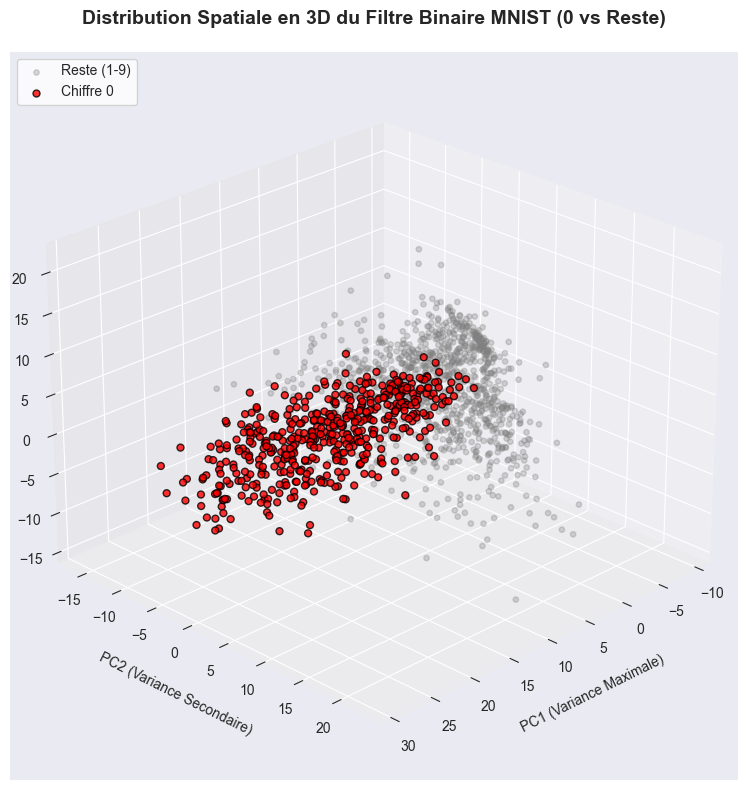

✅ Étape 9 complétée : Le nuage de points 3D a été projeté.
💡La 3D prouve que l'amas rouge (le 0) forme un cœur dense enveloppé par la masse grise des autres chiffres, ce qui valide scientifiquement le choix du noyau RBF.


In [14]:
# ============================================================================
# 9. VISUALISATION SPATIALE EN 3D (NUAGE DE POINTS PC1, PC2, PC3)
# ============================================================================
print("🎨 Préparation de la visualisation 3D (PCA 3 composantes)...")

# 1. Réduction à 3D
pca_3d = PCA(n_components=3, random_state=42)
X_train_3d = pca_3d.fit_transform(X_train_scaled)

# 2. Initialisation de la figure 3D
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

# Pour ne pas surcharger le graphique, on échantillonne 1000 points du Reste et 500 du Chiffre 0
idx_reste = np.where(y_train == 0)[0][:1000]
idx_zero = np.where(y_train == 1)[0][:500]

# 3. Affichage des points dans l'espace 3D
ax.scatter3D(X_train_3d[idx_reste, 0], X_train_3d[idx_reste, 1], X_train_3d[idx_reste, 2],
             c='gray', alpha=0.3, s=15, label='Reste (1-9)')

ax.scatter3D(X_train_3d[idx_zero, 0], X_train_3d[idx_zero, 1], X_train_3d[idx_zero, 2],
             c='red', alpha=0.8, s=25, edgecolors='black', label='Chiffre 0')

# 4. Habillage du graphique
ax.set_title("Distribution Spatiale en 3D du Filtre Binaire MNIST (0 vs Reste)", fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel("PC1 (Variance Maximale)", fontsize=10, labelpad=10)
ax.set_ylabel("PC2 (Variance Secondaire)", fontsize=10, labelpad=10)
ax.set_zlabel("PC3 (Axe de Profondeur)", fontsize=10, labelpad=10)

# Ajustement de l'angle de vue initial pour bien apprécier la séparation de l'amas
ax.view_init(elev=25, azim=45)

ax.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

print("✅ Étape 9 complétée : Le nuage de points 3D a été projeté.")
print("💡La 3D prouve que l'amas rouge (le 0) forme un cœur dense enveloppé par la masse grise des autres chiffres, ce qui valide scientifiquement le choix du noyau RBF.")